# GBD 2021 Sickle Cell Disease - Phase 2 Python Analysis

## Step 1. Setup - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# Show all columns when printing a DataFrame
pd.set_option('display.max_columns' , None)

# Format large numbers with commas (1000000 → 1,000,000.00)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Show up to 50 rows when printing
pd.set_option('display.max_rows' , 50)

print("Setup Complete")

Setup Complete


## 2. File Paths

In [3]:
DATA_PATH = r"C:\Users\fogac\Downloads\SCD Global Analysis Project\Phase 2 - Python\Data_Files"

# List all files in the folder to confirm Python can see them
all_files = os.listdir(DATA_PATH)
csv_files = [f for f in all_files if f.lower().endswith('.csv')]

print(f"Found {len(csv_files)} CSV files:")
for f in sorted(csv_files):
    print(f" {f}")

Found 5 CSV files:
 IHME_GBD_2021_SCD_2000_2021_CAUSE_615_Y2023M06D15.CSV
 IHME_GBD_2021_SCD_2000_2021_ME_18679_Y2023M06D15.CSV
 IHME_GBD_2021_SCD_2000_2021_ME_2097_Y2023M06D15.CSV
 IHME_GBD_2021_SCD_2000_2021_ME_2100_Y2023M06D15.CSV
 IHME_GBD_2021_SCD_2000_2021_ME_2103_Y2023M06D15.CSV


## 3. Loading the Data

In [4]:
cause615 = pd.read_csv(os.path.join(DATA_PATH, 'IHME_GBD_2021_SCD_2000_2021_CAUSE_615_Y2023M06D15.CSV'))

print(f"CAUSE_615: {len(cause615):,} rows, {len(cause615.columns)} columns")

CAUSE_615: 640,311 rows, 16 columns


In [5]:
# Remove all duplicate rows from cause_615
cause615 = cause615.drop_duplicates()

In [6]:
me18679 = pd.read_csv(os.path.join(DATA_PATH, 'IHME_GBD_2021_SCD_2000_2021_ME_18679_Y2023M06D15.CSV'))

print(f"ME_18679: {len(me18679):,} rows, {len(me18679.columns)} columns")

ME_18679: 254,520 rows, 16 columns


In [7]:
me2097 = pd.read_csv(os.path.join(DATA_PATH, 'IHME_GBD_2021_SCD_2000_2021_ME_2097_Y2023M06D15.CSV'))

print(f"ME_2097 (HbSS): {len(me2097):,} rows {len(me2097.columns)} columns")

ME_2097 (HbSS): 458,136 rows 16 columns


In [8]:
me2100 = pd.read_csv(os.path.join(DATA_PATH, "IHME_GBD_2021_SCD_2000_2021_ME_2100_Y2023M06D15.CSV"))

print(f"ME_2100 (HbSc): {len(me2100):,} rows {len(me2100.columns)} columns")

ME_2100 (HbSc): 458,136 rows 16 columns


In [9]:
me2103 = pd.read_csv(os.path.join(DATA_PATH, "IHME_GBD_2021_SCD_2000_2021_ME_2103_Y2023M06D15.CSV"))

print(f"ME_2103 (Sβ+): {len(me2103):,} rows {len(me2103.columns)} columns")

ME_2103 (Sβ+): 458,136 rows 16 columns


In [10]:
cause615['source_file'] = 'CAUSE_615'
me18679['source_file']  = 'ME_18679'
me2097['source_file']   = 'ME_2097'
me2100['source_file']   = 'ME_2100'
me2103['source_file']   = 'ME_2103'

print("Source labels added to all DataFrames")

Source labels added to all DataFrames


In [11]:
print("CAUSE_615 columns:")
print(list(cause615.columns))

print("\nME_18679 columns:")
print(list(me18679.columns))

CAUSE_615 columns:
['measure_id', 'measure_name', 'location_id', 'location_name', 'sex_id', 'sex_name', 'age_group_id', 'age_group_name', 'cause_id', 'cause_name', 'metric_id', 'metric_name', 'year_id', 'val', 'upper', 'lower', 'source_file']

ME_18679 columns:
['modelable_entity_id', 'modelable_entity_name', 'measure_id', 'measure_name', 'location_id', 'location_name', 'sex_id', 'sex_name', 'age_group_id', 'age_group_name', 'year_id', 'metric_id', 'metric_name', 'val', 'upper', 'lower', 'source_file']


### Checking for Missing Values

In [12]:
print("Null values in CAUSE_615:")
print(cause615.isnull().sum())

Null values in CAUSE_615:
measure_id        0
measure_name      0
location_id       0
location_name     0
sex_id            0
sex_name          0
age_group_id      0
age_group_name    0
cause_id          0
cause_name        0
metric_id         0
metric_name       0
year_id           0
val               0
upper             0
lower             0
source_file       0
dtype: int64


In [13]:
print("Null Values in ME_18679:")
print(me18679.isnull().sum())

Null Values in ME_18679:
modelable_entity_id      0
modelable_entity_name    0
measure_id               0
measure_name             0
location_id              0
location_name            0
sex_id                   0
sex_name                 0
age_group_id             0
age_group_name           0
year_id                  0
metric_id                0
metric_name              0
val                      0
upper                    0
lower                    0
source_file              0
dtype: int64


In [14]:
print("Null Values in ME_2097 (HbSS):")
print(me2097.isnull().sum())

Null Values in ME_2097 (HbSS):
modelable_entity_id      0
modelable_entity_name    0
measure_id               0
measure_name             0
location_id              0
location_name            0
sex_id                   0
sex_name                 0
age_group_id             0
age_group_name           0
year_id                  0
metric_id                0
metric_name              0
val                      0
upper                    0
lower                    0
source_file              0
dtype: int64


In [15]:
print("Null Values in ME_2100 (HbSc):")
print(me2100.isnull().sum())

Null Values in ME_2100 (HbSc):
modelable_entity_id      0
modelable_entity_name    0
measure_id               0
measure_name             0
location_id              0
location_name            0
sex_id                   0
sex_name                 0
age_group_id             0
age_group_name           0
year_id                  0
metric_id                0
metric_name              0
val                      0
upper                    0
lower                    0
source_file              0
dtype: int64


In [16]:
print("Null Values in ME_2103 (Sβ+):")
print(me2103.isnull().sum())

Null Values in ME_2103 (Sβ+):
modelable_entity_id      0
modelable_entity_name    0
measure_id               0
measure_name             0
location_id              0
location_name            0
sex_id                   0
sex_name                 0
age_group_id             0
age_group_name           0
year_id                  0
metric_id                0
metric_name              0
val                      0
upper                    0
lower                    0
source_file              0
dtype: int64


## Data Summary

All five files loaded successfully:
- CAUSE_615: 640,311 rows, 16 columns, 0 nulls
- ME_18679: 254,520 rows, 16 columns, 0 nulls
- ME_2097: 458,136 rows, 16 columns, 0 nulls
- ME_2100: 458,136 rows, 16 columns, 0 nulls
- ME_2103: 458,136 rows, 16 columns, 0 nulls

Source labels added to all DataFrames.
Ready to proceed to Step 2: Data Validation.

## Step 2. Data Validation

Duplicate Rows Check

In [17]:
print("Duplicate Row Check\n")

dataframes = {
    'CAUSE_615': cause615,
    'ME_18679': me18679,
    'ME_2087': me2097,
    'ME_2100': me2100,
    'ME_2103': me2103,
}

for name, df in dataframes.items():
    dupes = df.duplicated().sum()
    status = 'No duplicates' if dupes == 0 else f'ERROR - {dupes:,} duplicate rows found'
    print(f"{name}: {status}")

Duplicate Row Check

CAUSE_615: No duplicates
ME_18679: No duplicates
ME_2087: No duplicates
ME_2100: No duplicates
ME_2103: No duplicates


Key Duplicates Check

In [18]:
print("Duplicate Key Check\n")

# These are the columns that together identify a unique data point
key_columns = ['location_name', 'measure_name', 'metric_name', 'sex_name', 'age_group_name', 'year_id']

for name, df in dataframes.items():
    key_dupes = df.duplicated(subset=key_columns).sum()
    if key_dupes == 0:
        print(f"{name}: No duplicates")
    else:
        print(f"{name}: {key_dupes:,} key-level duplicaties found")

        # Show a sample of the duplicated combinations
        dupe_mask = df.duplicated(subset=key_columns, keep=False)
        sample = df[dupe_mask][key_columns + ['location_id', 'val']].drop_duplicates(
            subset=key_columns
        ).head(5)
        print(sample.to_string(index=True))
        print()


Duplicate Key Check

CAUSE_615: 69,996 key-level duplicaties found
  location_name measure_name metric_name sex_name age_group_name  year_id  location_id          val
0        Global   Prevalence      Number     Male          Birth     2000            1   911,214.85
1        Global   Prevalence      Number     Male          Birth     2005            1   973,140.81
2        Global   Prevalence      Number     Male          Birth     2010            1 1,052,035.37
3        Global   Prevalence      Number     Male          Birth     2015            1 1,087,146.80
4        Global   Prevalence      Number     Male          Birth     2020            1 1,115,806.18

ME_18679: 945 key-level duplicaties found
    location_name measure_name metric_name sex_name age_group_name  year_id  location_id  val
672       Georgia       Deaths      Number     Male        Under 5     2000           35 0.01
673       Georgia       Deaths      Number     Male        Under 5     2005           35 0.01
674     

### Known Location ID Duplicates — All Five Files

The following three locations have duplicate location_ids across all five files.
Filtering by location_name alone will produce incorrect results for these locations.

| Location | Duplicate IDs | Values | Fix |
|---|---|---|---|
| South Asia | 158 and 159 | Identical | Filter by location_id = 158 |
| North Africa and Middle East | 137 and 138 | Identical | Filter by location_id = 137 |
| Georgia | 35 and 533 | Different — ID 35 is the US state (near-zero), ID 533 is the country | Filter by location_id = 533 |

**When this matters:** Any query targeting South Asia, North Africa and Middle East,
or Georgia by name. Does not affect Global, Nigeria, or any other location.

**When this does not matter:** Queries targeting Global, top 10 countries,
or any location not in the table above.

Always use location_id for these three locations throughout the analysis.

### Location Duplication Issues

In [19]:
print("=== Location ID Duplication Verification ===\n")

locations_to_verify = [
    ('South Asia',                  158),
    ('North Africa and Middle East', 137),
]

for location_name, correct_id in locations_to_verify:
    print(f"--- {location_name} ---")

    # Filter by name — will find both IDs and double-count
    by_name = me18679[
        (me18679['location_name'] == location_name) &
        (me18679['measure_name'] == 'Deaths') &
        (me18679['metric_name'] == 'Number') &
        (me18679['sex_name'] == 'Both') &
        (me18679['age_group_name'] == 'All Ages') &
        (me18679['year_id'] == 2021)
    ]['val'].sum()

    # Filter by ID — finds only the correct row
    by_id = me18679[
        (me18679['location_id'] == correct_id) &
        (me18679['measure_name'] == 'Deaths') &
        (me18679['metric_name'] == 'Number') &
        (me18679['sex_name'] == 'Both') &
        (me18679['age_group_name'] == 'All Ages') &
        (me18679['year_id'] == 2021)
    ]['val'].sum()

    ratio = by_name / by_id

    print(f"  Filtered by name: {by_name:,.0f}")
    print(f"  Filtered by ID:   {by_id:,.0f}")
    print(f"  Ratio:            {ratio:.2f} — should be 2.00")
    print(f"  Double-count confirmed: {'YES' if abs(ratio - 2) < 0.01 else 'UNEXPECTED'}")
    print(f"  Correct value:    {by_id:,.0f} (use location_id = {correct_id})")
    print()

=== Location ID Duplication Verification ===

--- South Asia ---
  Filtered by name: 179,815
  Filtered by ID:   89,907
  Ratio:            2.00 — should be 2.00
  Double-count confirmed: YES
  Correct value:    89,907 (use location_id = 158)

--- North Africa and Middle East ---
  Filtered by name: 27,987
  Filtered by ID:   13,994
  Ratio:            2.00 — should be 2.00
  Double-count confirmed: YES
  Correct value:    13,994 (use location_id = 137)



### Missing Values

In [20]:
print("=== Missiing Values Check===\n")

for name, df in dataframes.items():
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()

    if total_nulls == 0:
        print(f"{name}: Hass no missing values")
    else:
        print(f"{name}: has {total_null:,} missing values")
        print(" Columns with nulls:")
        for column, count in null_count[null_count > 0].items():
            print(f"{column}: {count:,} nulls")
        print()

=== Missiing Values Check===

CAUSE_615: Hass no missing values
ME_18679: Hass no missing values
ME_2087: Hass no missing values
ME_2100: Hass no missing values
ME_2103: Hass no missing values


### Known Gap — 50 Plus Prevalence Not Published

In [21]:
print("=== 50 Plus Prevalence Check ===\n")

fifty_plus_prev = cause615[
    (cause615['measure_name'] == 'Prevalence') &
    (cause615['metric_name'] == 'Number') &
    (cause615['age_group_name'] == '50 plus') &
    (cause615['val'] > 0)
]

count = len(fifty_plus_prev)

if count == 0:
    print("CONFIRMED: No non-zero 50 plus Prevalence rows exist in CAUSE_615.")
    print("IHME did not publish Prevalence estimates for the 50 plus age group.")
    print("This explains the gap between the four age band sum and All Ages in Prevalence tables.")
else:
    print(f"UNEXPECTED: {count:,} non-zero 50 plus Prevalence rows found.")
    print("Investigate before proceeding.")

=== 50 Plus Prevalence Check ===

CONFIRMED: No non-zero 50 plus Prevalence rows exist in CAUSE_615.
IHME did not publish Prevalence estimates for the 50 plus age group.
This explains the gap between the four age band sum and All Ages in Prevalence tables.


## 3. Exploratory Data Analysis

### 3.1 Geographic Hierarchy

In [22]:
print("=== Geographic Structure ===\n")

# What is the expected row count for a fully populated location?
global_rows = len(cause615[cause615['location_name'] == 'Global'])
print(f"Global rows: {global_rows} — using this as the baseline for a fully populated location")

# Total unique locations
n_locations = cause615['location_name'].nunique()
print(f"Total unique locations in CAUSE_615: {n_locations:,}")
print(f"(Includes Global, super-regions, regions, countries, and sub-nationals)\n")

# Confirm key locations exist and check their row counts
locations_to_check = {
    'Global':                                          'Global',
    'Sub-Saharan Africa':                              'Super-region',
    'South Asia':                                      'Super-region',
    'North Africa and Middle East':                    'Super-region',
    'Southeast Asia, East Asia, and Oceania':          'Super-region',
    'Central Europe, Eastern Europe, and Central Asia':'Super-region',
    'Latin America and Caribbean':                     'Super-region',
    'High-income':                                     'Economic group',
    'Nigeria':                                         'Spotlight country',
}

print(f"{'Location':<50} {'Type':<20} {'Rows':>8}")
print("-" * 80)

for location, loc_type in locations_to_check.items():
    rows = len(cause615[cause615['location_name'] == location])
    note = " ← duplicate ID" if rows > 792 else ""
    print(f"{location:<50} {loc_type:<20} {rows:>8,}{note}")

=== Geographic Structure ===

Global rows: 792 — using this as the baseline for a fully populated location
Total unique locations in CAUSE_615: 805
(Includes Global, super-regions, regions, countries, and sub-nationals)

Location                                           Type                     Rows
--------------------------------------------------------------------------------
Global                                             Global                    792
Sub-Saharan Africa                                 Super-region              792
South Asia                                         Super-region            1,584 ← duplicate ID
North Africa and Middle East                       Super-region            1,584 ← duplicate ID
Southeast Asia, East Asia, and Oceania             Super-region              792
Central Europe, Eastern Europe, and Central Asia   Super-region              792
Latin America and Caribbean                        Super-region              792
High-income         

### Time Point Coverage

In [23]:
print("=== Time Point Coverage ===\n")

print("CAUSE_615 (Global level):")

# Deaths and Prevalence use All Ages
for measure in ['Deaths', 'Prevalence']:
    years = sorted([int(y) for y in cause615[
        (cause615['location_name'] == 'Global') &
        (cause615['measure_name'] == measure) &
        (cause615['metric_name'] == 'Number') &
        (cause615['sex_name'] == 'Both') &
        (cause615['age_group_name'] == 'All Ages')
    ]['year_id'].unique()])
    print(f"  {measure} (All Ages): {len(years)} time points — {years}")

# Incidence uses Birth age group
years_incidence = sorted([int(y) for y in cause615[
    (cause615['location_name'] == 'Global') &
    (cause615['measure_name'] == 'Incidence') &
    (cause615['metric_name'] == 'Number') &
    (cause615['sex_name'] == 'Both') &
    (cause615['age_group_name'] == 'Birth')
]['year_id'].unique()])
print(f"  Incidence (Birth):    {len(years_incidence)} time points — {years_incidence}")
print()

# Check ME_18679
print("ME_18679 (Global level):")
years_me = sorted([int(y) for y in me18679[
        (me18679['location_name'] == 'Global') &
        (me18679['measure_name'] == 'Deaths') &
        (me18679['metric_name'] == 'Number') &
        (me18679['sex_name'] == 'Both') &
        (me18679['age_group_name'] == 'All Ages')
    ]['year_id'].unique()])
print(f"  Deaths: {len(years_me)} time points — {years_me}")

=== Time Point Coverage ===

CAUSE_615 (Global level):
  Deaths (All Ages): 10 time points — [2000, 2005, 2010, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
  Prevalence (All Ages): 6 time points — [2000, 2005, 2010, 2015, 2020, 2021]
  Incidence (Birth):    6 time points — [2000, 2005, 2010, 2015, 2020, 2021]

ME_18679 (Global level):
  Deaths: 7 time points — [2000, 2005, 2010, 2015, 2019, 2020, 2021]


### Value Distribution — Country-Level Prevalence 2021

In [24]:
print("=== Country-Level Prevalence Distribution 2021 ===\n")

# Exclude known regional aggregates

exclude_regions = ['Global', 'Africa', 'Asia', 'Europe', 'America', 'Caribbean',
    'Oceania', 'income', 'Saharan', 'Latin', 'Southeast', 'Tropical',
    'Andean', 'South Asia', 'East Asia', 'Australasia']

exclude_mask = cause615['location_name'].str.contains('|'.join(exclude_regions), case=False, na=False)

country_prevalance = cause615[
    (~exclude_mask) &
    (cause615['measure_name'] == 'Prevalence') &
    (cause615['metric_name'] == 'Number') &
    (cause615['sex_name'] == 'Both') &
    (cause615['age_group_name'] == 'All Ages') &
    (cause615['year_id'] == 2021)
].groupby('location_name')['val'].sum().reset_index()

country_prevalance.columns = ['country', 'prevalence_2021']
country_prevalance = country_prevalance.sort_values('prevalence_2021', ascending = False).reset_index(drop=True)

print(f"Locations with prevalence data: {len(country_prevalance):,}\n")
print("Top 10:")
print(country_prevalance.head(10).to_string(index=False))

=== Country-Level Prevalence Distribution 2021 ===

Locations with prevalence data: 773

Top 10:
                         country  prevalence_2021
                         Nigeria     2,591,202.20
                           India     1,280,366.81
Democratic Republic of the Congo       654,987.35
                    Burkina Faso       281,449.07
                           Kenya       263,897.53
                           Ghana       238,944.51
                           Benin       181,563.13
                          Angola       181,508.11
     United Republic of Tanzania       164,186.31
                           Niger       156,878.58


In [25]:
stats = country_prevalance['prevalence_2021'].describe()
print("Summary statistics:")
print(stats.round(0))

Summary statistics:
count         773.00
mean       10,479.00
std       108,958.00
min             0.00
25%             2.00
50%            19.00
75%           523.00
max     2,591,202.00
Name: prevalence_2021, dtype: float64


In [26]:
print(f"\nNigeria Prevalence: {country_prevalance.iloc[1]['prevalence_2021']:,.0f}")
print(f"Median country:        {stats['50%']:,.0f}")
print(f"Nigeria vs median:     {country_prevalance.iloc[0]['prevalence_2021'] / stats['50%']:.1f}x higher")

global_prevalence = 7741879
top5_sum = country_prevalance.head(5)['prevalence_2021'].sum()
print(f"\nTop 5 countries share of global total: {top5_sum / global_prevalence * 100:.1f}%")


Nigeria Prevalence: 1,280,367
Median country:        19
Nigeria vs median:     137523.7x higher

Top 5 countries share of global total: 65.5%


### Top 20 Countries Chart

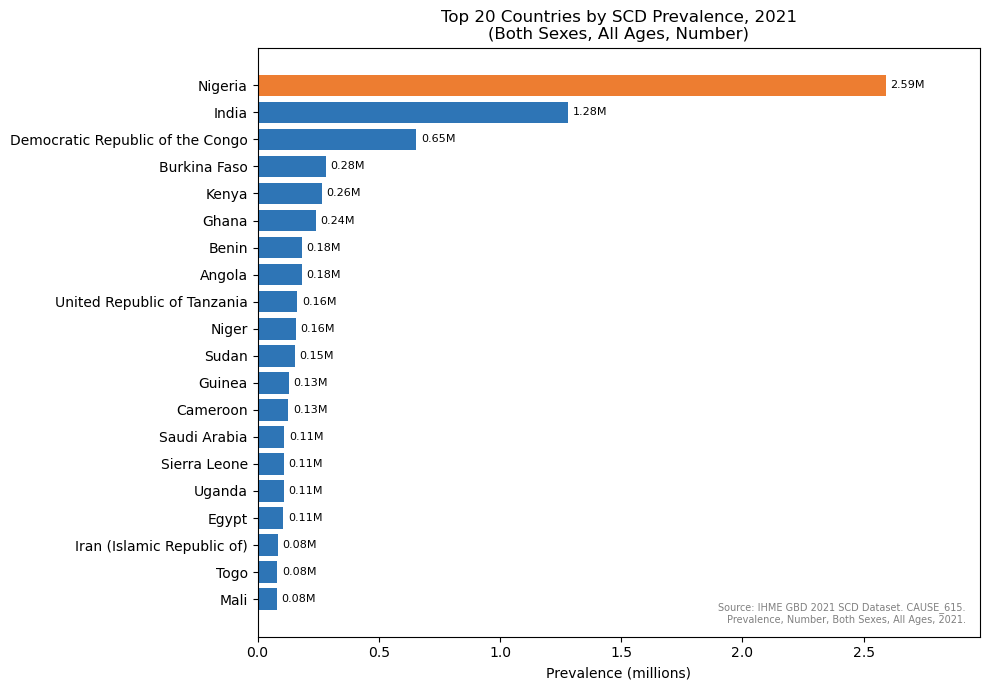

Chart saved as top20_prevalence.png


In [38]:
top20 = country_prevalance.head(20).copy()
colours = ['#ED7D31' if c == 'Nigeria' else '#2E75B6' for c in top20['country']]

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(top20['country'], top20['prevalence_2021'] / 1e6, color=colours)
ax.invert_yaxis()
ax.set_xlabel('Prevalence (millions)')
ax.set_title('Top 20 Countries by SCD Prevalence, 2021\n(Both Sexes, All Ages, Number)')
ax.set_xlim(0, top20['prevalence_2021'].max() / 1e6 * 1.15)

# Data labels
for i, (val, country) in enumerate(zip(top20['prevalence_2021'], top20['country'])):
    ax.text(val / 1e6 + 0.02, i, f"{val/1e6:.2f}M", va='center', fontsize=8)

ax.text(0.98, 0.02, 'Source: IHME GBD 2021 SCD Dataset. CAUSE_615.\nPrevalence, Number, Both Sexes, All Ages, 2021.',
        transform=ax.transAxes, fontsize=7, ha='right', va='bottom', color='gray')

plt.tight_layout()
plt.savefig('top20_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as top20_prevalence.png")

### Birth Incidence vs Prevalence Ratio — Survival Signal

In [40]:
print("=== Birth Incidence vs Prevalence Ratio 2021 ===\n")
print("Higher ratio = larger living population relative to annual new births")
print("= signal of improving survival\n")

# Prevalence 2021 by country
prev_2021 = cause615[
    (~exclude_mask) &
    (cause615['measure_name'] == 'Prevalence') &
    (cause615['metric_name'] == 'Number') &
    (cause615['sex_name'] == 'Both') &
    (cause615['age_group_name'] == 'All Ages') &
    (cause615['year_id'] == 2021)
].groupby('location_name')['val'].sum().reset_index()
prev_2021.columns = ['country', 'prevalence']

# Birth incidence 2021 by country
# drop_duplicates handles the Birth duplication issue from Step 2
birth_2021 = cause615[
    (~exclude_mask) &
    (cause615['measure_name'] == 'Incidence') &
    (cause615['metric_name'] == 'Number') &
    (cause615['sex_name'] == 'Both') &
    (cause615['age_group_name'] == 'Birth') &
    (cause615['year_id'] == 2021)
].drop_duplicates(
    subset=['location_name', 'measure_name', 'metric_name', 'sex_name', 'age_group_name', 'year_id']
).groupby('location_name')['val'].sum().reset_index()
birth_2021.columns = ['country', 'birth_incidence']

# Merge and calculate ratio
ratio_df = prev_2021.merge(birth_2021, on='country', how='inner')
ratio_df = ratio_df[ratio_df['birth_incidence'] > 100].copy()
ratio_df['ratio'] = (ratio_df['prevalence'] / ratio_df['birth_incidence']).round(1)
ratio_df = ratio_df.sort_values('ratio', ascending=False).reset_index(drop=True)

print("Countries with HIGHEST ratio (strongest survival signal):")
print(ratio_df.head(10)[['country', 'prevalence', 'birth_incidence', 'ratio']].to_string(index=False))

print("\nCountries with LOWEST ratio:")
print(ratio_df.tail(10)[['country', 'prevalence', 'birth_incidence', 'ratio']].to_string(index=False))

# Nigeria
nigeria = ratio_df[ratio_df['country'] == 'Nigeria']
if len(nigeria) > 0:
    row = nigeria.iloc[0]
    print(f"\nNigeria:")
    print(f"  Prevalence:      {row['prevalence']:,.0f}")
    print(f"  Birth incidence: {row['birth_incidence']:,.0f}")
    print(f"  Ratio:           {row['ratio']:.1f}")
    rank = ratio_df.index[ratio_df['country'] == 'Nigeria'].tolist()[0] + 1
    print(f"  Rank:            {rank} of {len(ratio_df)}")

=== Birth Incidence vs Prevalence Ratio 2021 ===

Higher ratio = larger living population relative to annual new births
= signal of improving survival

Countries with HIGHEST ratio (strongest survival signal):
                   country  prevalence  birth_incidence  ratio
                   Bahrain    9,325.06           125.63  74.20
              Saudi Arabia  109,280.55         1,697.86  64.40
                  New York    6,441.84           115.73  55.70
                   Florida    7,071.38           134.03  52.80
                    Tehran   12,515.48           250.24  50.00
                     Texas    5,630.19           122.13  46.10
                      Fars    5,090.67           115.39  44.10
Iran (Islamic Republic of)   82,180.81         1,963.22  41.90
                   Tunisia    6,673.14           167.26  39.90
                     China   21,234.03           562.11  37.80

Countries with LOWEST ratio:
           country  prevalence  birth_incidence  ratio
            

## Analysis Tables

### Query Function

In [41]:
def query_val(df, location, measure, metric, sex, age_group, year,
              use_location_id=False):
    """
    Filter a DataFrame and return the sum of the val column.

    Parameters:
    df           : the DataFrame to query (cause615 or me18679)
    location     : location_name string OR location_id integer
    measure      : measure_name string (Deaths, Prevalence, Incidence)
    metric       : metric_name string (Number, Rate, Percent)
    sex          : sex_name string (Both, Male, Female)
    age_group    : age_group_name string (All Ages, Birth, Under 5, etc.)
    year         : year_id integer
    use_location_id : if True, filter by location_id instead of location_name
                      use for South Asia (158), North Africa (137), Georgia (533)
    """
    if use_location_id:
        mask = (
            (df['location_id'] == location) &
            (df['measure_name'] == measure) &
            (df['metric_name'] == metric) &
            (df['sex_name'] == sex) &
            (df['age_group_name'] == age_group) &
            (df['year_id'] == year)
        )
    else:
        mask = (
            (df['location_name'] == location) &
            (df['measure_name'] == measure) &
            (df['metric_name'] == metric) &
            (df['sex_name'] == sex) &
            (df['age_group_name'] == age_group) &
            (df['year_id'] == year)
        )

    return df[mask]['val'].sum()

In [46]:
# Quick test
test = query_val(me18679, 'Global', 'Deaths', 'Number', 'Both', 'All Ages', 2021)
print(f"Test — Global Deaths 2021: {test:,.0f}")

Test — Global Deaths 2021: 375,828


### Table 1 — Global Annual Deaths Trend (ME_18679)

In [52]:
print("=== Table 1: Global Annual Deaths Trend ===\n")
print(f"Source: ME_18679 | Measure: Deaths | Metric: Number | Sex: Both | Age: All Ages\n")

years_me = [2000, 2005, 2010, 2015, 2019, 2020, 2021]

results = []
for year in years_me:
    val = query_val(me18679, 'Global', 'Deaths', 'Number', 'Both', 'All Ages', year)
    results.append({'Year': year, 'Deaths': val})

table1 = pd.DataFrame(results)
table1['Deaths'] = table1['Deaths'].round(0).astype(int)

# year-on-year percentage change
table1['Change'] = table1['Deaths'].pct_change() * 100
table1['Change'] = table1['Change'].apply(lambda x: f"+{x:.1f}%" if x > 0 else f"{x:.1f}%" if pd.notna(x) else "Baseline")

print(table1.to_string(index=False))
print(f"\nTotal 2000-2021 change: +{(table1['Deaths'].iloc[-1] - table1['Deaths'].iloc[0]) / table1['Deaths'].iloc[0] * 100:.1f}%")

=== Table 1: Global Annual Deaths Trend ===

Source: ME_18679 | Measure: Deaths | Metric: Number | Sex: Both | Age: All Ages

 Year  Deaths   Change
 2000  262028 Baseline
 2005  284511    +8.6%
 2010  314322   +10.5%
 2015  341687    +8.7%
 2019  364427    +6.7%
 2020  371271    +1.9%
 2021  375828    +1.2%

Total 2000-2021 change: +43.4%


### Table 2 — Top Countries by SCD Prevalence 2021

In [55]:
print("=== Table 2: Top Countries by SCD Prevalence 2021 ===\n")
print(f"Source: CAUSE_615 | Measure: Prevalence | Metric: Number | Sex: Both | Age: All Ages\n")

# Exclude regional aggregates
exclude_terms = [
    'Global', 'Africa', 'Asia', 'Europe', 'America', 'Caribbean',
    'Oceania', 'income', 'Saharan', 'Latin', 'Southeast', 'Tropical',
    'Andean', 'South Asia', 'East Asia', 'Australasia'
]
exclude_mask = cause615['location_name'].str.contains(
    '|'.join(exclude_terms), case=False, na=False
)

country_prev = cause615[
    (~exclude_mask) &
    (cause615['measure_name'] == 'Prevalence') &
    (cause615['metric_name'] == 'Number') &
    (cause615['sex_name'] == 'Both') &
    (cause615['age_group_name'] == 'All Ages') &
    (cause615['year_id'] == 2021)
].groupby('location_name')['val'].sum().reset_index()

country_prev.columns = ['Country', 'Prevalence_2021']
country_prev = country_prev.sort_values('Prevalence_2021', ascending=False).reset_index(drop=True)
country_prev['Rank'] = country_prev.index + 1

# Add share of global total
global_prev_2021 = query_val(cause615, 'Global', 'Prevalence', 'Number', 'Both', 'All Ages', 2021)
country_prev['Share_of_Global'] = (country_prev['Prevalence_2021'] / global_prev_2021 * 100).round(1)
country_prev['Share_of_Global'] = country_prev['Share_of_Global'].apply(lambda x: f"{x:.1f}%")

top10 = country_prev.head(10)[['Rank', 'Country', 'Prevalence_2021', 'Share_of_Global']].copy()
top10['Prevalence_2021'] = top10['Prevalence_2021'].apply(lambda x: f"{x:,.0f}")

print(top10.to_string(index=False))

=== Table 2: Top Countries by SCD Prevalence 2021 ===

Source: CAUSE_615 | Measure: Prevalence | Metric: Number | Sex: Both | Age: All Ages

 Rank                          Country Prevalence_2021 Share_of_Global
    1                          Nigeria       2,591,202           33.5%
    2                            India       1,280,367           16.5%
    3 Democratic Republic of the Congo         654,987            8.5%
    4                     Burkina Faso         281,449            3.6%
    5                            Kenya         263,898            3.4%
    6                            Ghana         238,945            3.1%
    7                            Benin         181,563            2.3%
    8                           Angola         181,508            2.3%
    9      United Republic of Tanzania         164,186            2.1%
   10                            Niger         156,879            2.0%


### Table 3 — Regional Mortality Comparison (ME_18679)

In [56]:
print("=== Table 3: Regional Mortality Comparison ===\n")
print("Source: ME_18679 | Measure: Deaths | Metric: Number | Sex: Both | Age: All Ages\n")
print("Note: South Asia filtered by location_id=158, North Africa by location_id=137\n")

regions = [
    ('Sub-Saharan Africa',                              False),
    ('South Asia',                                      True),   # use location_id = 158
    ('North Africa and Middle East',                    True),   # use location_id = 137
    ('Latin America and Caribbean',                     False),
    ('Southeast Asia, East Asia, and Oceania',          False),
    ('Central Europe, Eastern Europe, and Central Asia',False),
]

# location_id mapping for regions that need it
region_ids = {
    'South Asia': 158,
    'North Africa and Middle East': 137,
}

years_me = [2000, 2005, 2010, 2015, 2019, 2020, 2021]

rows = []
for region, use_id in regions:
    location = region_ids.get(region, region)
    row = {'Region': region}
    for year in years_me:
        val = query_val(me18679, location, 'Deaths', 'Number', 'Both', 'All Ages', year,
                        use_location_id=use_id)
        row[str(year)] = round(val, 0)
    rows.append(row)

table3 = pd.DataFrame(rows)

# Format numbers with commas
for year in years_me:
    table3[str(year)] = table3[str(year)].apply(lambda x: f"{x:,.0f}")

print(table3.to_string(index=False))

=== Table 3: Regional Mortality Comparison ===

Source: ME_18679 | Measure: Deaths | Metric: Number | Sex: Both | Age: All Ages

Note: South Asia filtered by location_id=158, North Africa by location_id=137

                                          Region    2000    2005    2010    2015    2019    2020    2021
                              Sub-Saharan Africa 160,249 177,386 201,752 230,012 252,191 259,312 264,535
                                      South Asia  81,285  86,144  89,529  90,318  90,076  89,613  89,907
                    North Africa and Middle East  13,507  13,835  15,812  14,051  14,534  14,814  13,994
                     Latin America and Caribbean   3,459   3,567   3,588   3,734   4,086   4,087   4,078
          Southeast Asia, East Asia, and Oceania     754     757     769     759     755     750     744
Central Europe, Eastern Europe, and Central Asia      55      36      35      37      35      36      35


### Table 4 — Global Deaths by Sex (ME_18679)